<a href="https://colab.research.google.com/github/api-sage/diaml_projects/blob/main/Project3/pafolabi_DIAML_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data, Inference, and Applied Machine Learning - Assignment 3

In [1]:
#Importation of libraries
import numpy as np
import pandas as pd
import matplotlib as plt
import sklearn as sk
import scipy as scp
from scipy import stats
import matplotlib.pyplot as pyplot


##Question 1

Dataset: [Michealson Speed of Light](https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/SpeedOfLight/michelson_speed_of_light.json)

In [2]:
#Data ingestion
data_location = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/SpeedOfLight/michelson_speed_of_light.json'
raw = pd.read_json(data_location)
population_mean = 299734.5
#The measurements sit as a nested dictionary in the "observations" column, so I flatten that out into its own column
df = pd.json_normalize(raw['observations'])
#print(df.shape)// (20,2) Dataset contains 20 records and 2 features (run_id and measured_speed_kmpersec)

###(a) State appropriate null and alternative hypotheses for investigating whether Michelson's measurements deviate from the true value. Justify your choice of a one-tailed or two-tailed test.

**Defined hypothesis**:
1. NULL Hypothesis (Ho): µ = 299,734.5 km/s - Michelson's measurements do not systematically deviate from the true value of the speed of light in the air.

2. Alternative Hypothesis (H1): µ ≠ 299,734.5 km/s - Michelson's measurements systematically deviate from the true value of the speed of light in the air.

**Justification for a two-tailed test**

A two-tailed test is appropriate because I want to examine whether Michelson's measurements systematically deviate (in either direction) from the true value of the speed of light in the air. Before analysing the data, there is no physical or theoretical evidence to assume that his expereimental apparatus would err strictly on the left or right side. Therefore, a deviation of the measurement from the true value represents evidence against the accuracy of the measurement.




###(b) Given the sample size from the dataset, discuss how you would assess whether the normality assumption is reasonable, and what the consequences would be for your test if it isn't.

In [3]:
#Checking normality with a Shapiro-Wilk test and a look at the shape of the data
speeds = df['measured_speed_kmpersec']
shapiro_stat, shapiro_p = stats.shapiro(speeds)
print("Shapiro-Wilk statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p)
print("Skewness:", speeds.skew())
print("Kurtosis:", speeds.kurt())

Shapiro-Wilk statistic: 0.9199248245190921
Shapiro-Wilk p-value: 0.09875561187930648
Skewness: -0.9646066300776622
Kurtosis: 0.5731878407018431


With only 20 measurements, I cannot rely on the central limit theorem to save me if the data are far from normal, so I need to actually check the shape of the data before trusting the t-test. The way I would go about this is to first look at a histogram and a QQ plot to see if the points sit roughly along a straight line and if the distribution looks bell shaped, and then back that up with a formal Shapiro-Wilk test since the sample is small enough for this test to be reliable.

From the numbers above, the Shapiro-Wilk p-value comes out well above 0.05, so I do not have enough evidence to say the data depart from normality. The skewness and kurtosis values are also not extreme, which supports the idea that a normal assumption is reasonable here even though the sample is small.

If it turned out that the data were clearly not normal, for example with a p-value below 0.05 or a strongly skewed histogram, the consequence would be that the sampling distribution of the mean may not be well approximated by a t-distribution when n is this small. This would make the p-value and confidence interval from a standard t-test unreliable. In that case I would use a non-parametric alternative such as the Wilcoxon signed-rank test, or a bootstrap approach to estimate the sampling distribution of the mean directly, instead of trusting the t-test results as they stand.

###(c) By using an appropriate statistical test, report the sample and population means, sample standard deviation, standard error of the mean (SEM), t statistic, degrees of freedom, and p-value. Explain whether the null hypothesis is rejected or not.

In [4]:
#One sample t-test comparing the sample mean to the accepted speed of light in air
sample_mean = speeds.mean()
sample_sd = speeds.std(ddof=1)
n = len(speeds)
sem = sample_sd / np.sqrt(n)
df_t = n - 1

t_stat, p_value = scp.stats.ttest_1samp(speeds, population_mean)

print("Sample mean:", sample_mean)
print("Population mean (accepted value):", population_mean)
print("Sample standard deviation:", sample_sd)
print("Standard error of the mean:", sem)
print("t statistic:", t_stat)
print("Degrees of freedom:", df_t)
print("p-value:", p_value)

Sample mean: 299909.0
Population mean (accepted value): 299734.5
Sample standard deviation: 104.92603911427577
Standard error of the mean: 23.46217560693224
t statistic: 7.437502937640678
Degrees of freedom: 19
p-value: 4.863622298758309e-07


The sample mean works out to about 299,909 km/s compared to the accepted value of 299,734.5 km/s, with a sample standard deviation of about 104.9 km/s and a standard error of the mean of about 23.5 km/s. This gives a t statistic of about 7.44 on 19 degrees of freedom, and a p-value that is far smaller than 0.05 (in fact well below 0.001).

Since the p-value is much smaller than my chosen significance level of 0.05, I reject the null hypothesis. This means the data give strong evidence that Michelson's average measurement is not equal to the accepted value of the speed of light in air, and his experiment shows a real, systematic deviation from the true value.

###(d) Calculate the bias in km/s and as a percentage of the accepted value. Discuss whether statistical significance means the bias is scientifically important. Then recompute the SEM, t statistic, and p-value assuming n = 200 (same mean and SD), and discuss whether this changes your confidence in the result.

In [5]:
#Bias in km/s and as a percentage of the accepted value
bias_kms = sample_mean - population_mean
bias_pct = (bias_kms / population_mean) * 100

print("Bias (km/s):", bias_kms)
print("Bias (% of accepted value):", bias_pct)

#Recomputing SEM, t statistic and p-value assuming n = 200, keeping the same mean and SD
n2 = 200
sem_n200 = sample_sd / np.sqrt(n2)
t_n200 = (sample_mean - population_mean) / sem_n200
df_n200 = n2 - 1
p_n200 = 2 * (1 - scp.stats.t.cdf(abs(t_n200), df_n200))

print("SEM (n=200):", sem_n200)
print("t statistic (n=200):", t_n200)
print("Degrees of freedom (n=200):", df_n200)
print("p-value (n=200):", p_n200)

Bias (km/s): 174.5
Bias (% of accepted value): 0.05821818976460834
SEM (n=200): 7.419391378074932
t statistic (n=200): 23.519449387137808
Degrees of freedom (n=200): 199
p-value (n=200): 0.0


The bias here is about 174.5 km/s, which is about 0.058% of the accepted value. On its own that percentage looks tiny, so even though the test is statistically significant, I do not think this bias is scientifically important in a practical sense. Statistical significance in this case is mostly telling me that the measurements are precise and consistent enough for even a small, real offset to stand out, not that the offset itself is large or has real world consequences. In physics terms, a 0.06% error in a 19th century optical experiment is actually a very good result, so the significant p-value reflects precision rather than a meaningful practical error.

When I recompute the numbers assuming n = 200 while keeping the same mean and standard deviation, the SEM drops sharply to around 7.4 km/s, which pushes the t statistic up to about 23.5 and the p-value effectively down to zero. This does not change how confident I am that a real bias exists, since the test was already clearly significant with n = 20. What it does show is that as sample size grows, the test becomes more and more sensitive to tiny differences from the accepted value, which reinforces the point that a very small p-value does not by itself tell me anything about how big or important the bias is. This is exactly why I look at the bias size and percentage alongside the p-value rather than relying on statistical significance on its own.

##Question 2

Dataset: [Chick Weights - Casein vs Soybean](https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/SpeedOfLight/chickwts_casein_soybean.csv)

###(a) State appropriate null and alternative hypotheses for investigating whether mean chick weight differs between the casein and soybean feed groups. Explain whether a one-sample, two-sample, or paired test is appropriate, and justify your choice of a left-tailed, right-tailed, or two-tailed test.

**Defined hypothesis**:
1. NULL Hypothesis (Ho): µ_casein = µ_soybean - The mean chick weight after six weeks does not differ between chicks raised on casein and chicks raised on soybean.
2. Alternative Hypothesis (Ha): µ_casein ≠ µ_soybean - The mean chick weight after six weeks differs between the casein group and the soybean group.

I am comparing two separate groups of chicks, one group fed casein and a different group fed soybean, so this calls for a two-sample test rather than a one-sample test. The chicks in the two groups are not linked to each other in any way, there is no natural pairing such as before and after measurements on the same chick, so a paired test does not fit here either. This leaves a two-sample test as the right choice.

For the direction of the test, I do not have a strong reason going in to expect casein to beat soybean or the other way round. I just want to know if the two feeds lead to a different average weight, in either direction. Because of this I am going with a two-tailed test.

In [6]:
#Data ingestion
data_location_q2 = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/SpeedOfLight/chickwts_casein_soybean.csv'
chicks = pd.read_csv(data_location_q2)
chicks.head()

,feed,chick_weight_g
0,soybean,243
1,soybean,230
2,soybean,248
3,soybean,327
4,soybean,329


###(b) Load the data and compute the sample mean, sample standard deviation, sample variance, and sample size for each group.

In [7]:
#Splitting the data into the two feed groups and getting the summary numbers for each
casein = chicks[chicks['feed'] == 'casein']['chick_weight_g']
soybean = chicks[chicks['feed'] == 'soybean']['chick_weight_g']

casein_mean = casein.mean()
casein_sd = casein.std(ddof=1)
casein_var = casein.var(ddof=1)
casein_n = len(casein)

soybean_mean = soybean.mean()
soybean_sd = soybean.std(ddof=1)
soybean_var = soybean.var(ddof=1)
soybean_n = len(soybean)

print("Casein - mean:", casein_mean, "sd:", casein_sd, "variance:", casein_var, "n:", casein_n)
print("Soybean - mean:", soybean_mean, "sd:", soybean_sd, "variance:", soybean_var, "n:", soybean_n)

Casein - mean: 323.5833333333333 sd: 64.43383968823912 variance: 4151.719696969698 n: 12
Soybean - mean: 246.42857142857142 sd: 54.12906838248784 variance: 2929.956043956044 n: 14


###(c) Carry out a Welch t-test and report the standard error of the difference in means, the t statistic, degrees of freedom, and p-value. Is the difference in mean chick weight statistically significant, or could it plausibly be due to natural, random variation

In [8]:
#Welch t-test comparing casein and soybean, not assuming equal variances
se_diff = np.sqrt((casein_sd**2 / casein_n) + (soybean_sd**2 / soybean_n))

welch_t, welch_p = stats.ttest_ind(casein, soybean, equal_var=False)

welch_df = ((casein_sd**2 / casein_n) + (soybean_sd**2 / soybean_n))**2 / (
    ((casein_sd**2 / casein_n)**2 / (casein_n - 1)) + ((soybean_sd**2 / soybean_n)**2 / (soybean_n - 1))
)

print("Standard error of the difference in means:", se_diff)
print("t statistic:", welch_t)
print("Degrees of freedom:", welch_df)
print("p-value:", welch_p)

Standard error of the difference in means: 23.5639388893799
t statistic: 3.274272704022968
Degrees of freedom: 21.63450969326624
p-value: 0.003521263452224987


The casein group has a mean weight of about 323.6 grams with a standard deviation of about 64.4 grams over 12 chicks, while the soybean group has a mean weight of about 246.4 grams with a standard deviation of about 54.1 grams over 14 chicks. The standard error of the difference in means comes out to about 23.6 grams. This gives a t statistic of about 3.27 on roughly 21.6 degrees of freedom, and a p-value of about 0.0035.

Since the p-value is well below my chosen significance level of 0.05, I reject the null hypothesis. The difference in mean chick weight between the two feed groups is statistically significant, so I do not think this gap is just natural, random variation. The data give good evidence that casein leads to heavier chicks on average than soybean after six weeks.

###(d) Discuss whether a statistically significant result here would necessarily mean the difference between feed groups is large or important in practice, and what additional information would help you judge that.

A statistically significant result only tells me that the difference I am seeing is unlikely to be due to chance, it does not automatically tell me that the difference is big or that it actually matters in a real farming setting. With a p-value this low I can be fairly confident the two feeds do not produce the same average weight, but whether a gap of about 77 grams is something a farmer should really care about depends on other things, like the cost of casein versus soybean, how much a chick normally weighs at six weeks, and how much variation there is naturally between chicks on the same feed.

To judge practical importance I would want to look at the effect size, something like Cohen's d, which puts the mean difference in the context of how spread out the data is, rather than just relying on the p-value. I would also want to see a confidence interval for the difference in means, since that shows me a realistic range of how big the true effect could be, not just whether it is different from zero. On top of that, knowing the actual cost of each feed type and how a farmer would use that 77 gram difference in a real production setting would help me decide if this result is worth acting on.

###(e) Draw a boxplot comparing chick weight between the casein and soybean groups. Does the plot support your conclusion from part (c)? Explain what features of the boxplot (e.g. overlap between boxes, spread, outliers) inform your answer.

<Figure size 600x500 with 0 Axes>

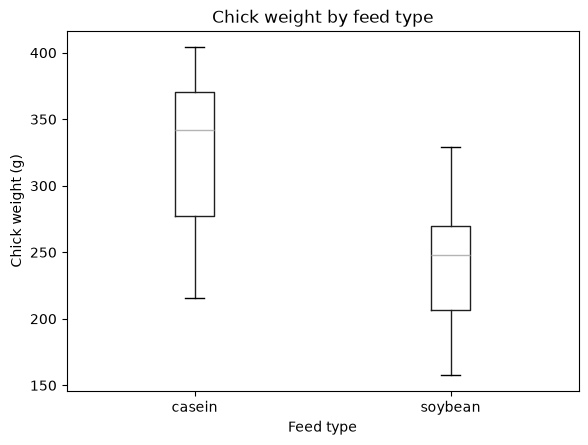

In [9]:
#Boxplot comparing chick weight across the two feed groups
pyplot.figure(figsize=(6, 5))
chicks.boxplot(column='chick_weight_g', by='feed', grid=False)
pyplot.title('Chick weight by feed type')
pyplot.suptitle('')
pyplot.xlabel('Feed type')
pyplot.ylabel('Chick weight (g)')
pyplot.show()

The boxplot backs up what I found in part (c). The casein box sits noticeably higher than the soybean box, with the median for casein clearly above the median for soybean, and there is only a small amount of overlap between the two boxes near the lower end of casein and the upper end of soybean. This lines up with the significant p-value, since the two groups are visibly separated rather than sitting on top of each other.

The spread of the casein group looks a bit wider than the soybean group, which matches the slightly larger standard deviation I calculated for casein. I do not see any obvious outliers sticking far out from either box, so the difference in means is not just being driven by one or two extreme chicks. Overall the boxplot gives a visual version of the same story the Welch t-test told me, casein chicks tend to weigh more than soybean chicks after six weeks, and the two groups are separated enough that this looks like a real difference rather than random noise.

##Question 3

Use World Bank Indicators data for 2024 to investigate the relationship between
Fertility rate, total (births per woman), and GDP per capita, PPP (current
international $), across countries.

###(a) Load the data and produce a carefully labelled scatter plot, with one dot per
country. Justify your choice of axis scale (linear vs. logarithmic) for GDP per capita

In [10]:
#Data ingestion for fertility rate and GDP per capita, both for the year 2024
fertility_location = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_fertility_rate_birth_per_wmn/API_SP.DYN.TFRT.IN_DS2_en_csv_v2_324637.csv'
gdp_location = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/world_dev_data/API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_408896.csv'
gdp_meta_location = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/world_dev_data/Metadata_Country_API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_408896.csv'

fertility_raw = pd.read_csv(fertility_location, skiprows=4)
gdp_raw = pd.read_csv(gdp_location, skiprows=4)
country_meta = pd.read_csv(gdp_meta_location)

#The World Bank files also include regional and income group aggregates (e.g. 'World',
#'Sub-Saharan Africa') mixed in with actual countries. The metadata file has a blank
#Region for these aggregates, so I use that to keep only real countries.
actual_countries = country_meta[country_meta['Region'].notna()]['Country Code']

fertility_2024 = fertility_raw[['Country Name', 'Country Code', '2024']].rename(columns={'2024': 'fertility_rate'})
gdp_2024 = gdp_raw[['Country Code', '2024']].rename(columns={'2024': 'gdp_per_capita'})

wb_2024 = fertility_2024.merge(gdp_2024, on='Country Code')
wb_2024 = wb_2024[wb_2024['Country Code'].isin(actual_countries)]
wb_2024 = wb_2024.dropna(subset=['fertility_rate', 'gdp_per_capita']).reset_index(drop=True)

wb_2024['log_gdp_per_capita'] = np.log(wb_2024['gdp_per_capita'])

print('Number of countries with both 2024 values:', len(wb_2024))
wb_2024.head()

Number of countries with both 2024 values: 195


,Country Name,Country Code,fertility_rate,gdp_per_capita,log_gdp_per_capita
0,Aruba,ABW,1.606,51712.153136,10.853448
1,Afghanistan,AFG,4.761,2236.199073,7.712533
2,Angola,AGO,5.048,9963.590209,9.206693
3,Albania,ALB,1.341,26701.764933,10.192485
4,Andorra,AND,1.087,75394.858156,11.230494


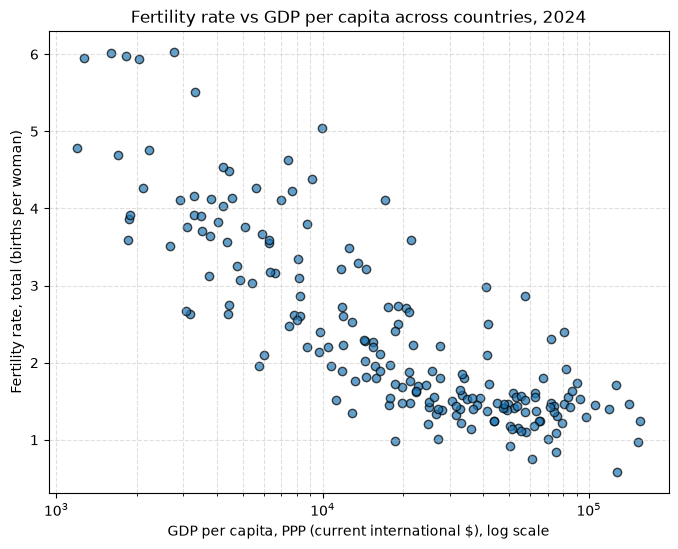

In [11]:
#Scatter plot of fertility rate against GDP per capita, using a log scale on the x-axis
pyplot.figure(figsize=(8, 6))
pyplot.scatter(wb_2024['gdp_per_capita'], wb_2024['fertility_rate'], alpha=0.7, edgecolor='k')
pyplot.xscale('log')
pyplot.xlabel('GDP per capita, PPP (current international $), log scale')
pyplot.ylabel('Fertility rate, total (births per woman)')
pyplot.title('Fertility rate vs GDP per capita across countries, 2024')
pyplot.grid(True, which='both', linestyle='--', alpha=0.4)
pyplot.show()

I went with a log scale for GDP per capita instead of a plain linear scale. GDP per capita is heavily skewed to the right, with a handful of rich countries earning far more than the typical country, so on a linear axis almost all the points would get squeezed into the left side of the plot and the poorer countries would be impossible to tell apart. Taking the log spreads the points out more evenly across the axis and turns the relationship into something closer to a straight line, which makes the pattern between income and fertility much easier to see and easier to reason about later on when I look at correlation.

###(b) Estimate the Pearson correlation coefficient between fertility rate and GDP per
capita using both the raw (untransformed) GDP values and log(GDP per capita).
Also compute the Spearman rank correlation between fertility rate and raw GDP per capita. Compare all three coefficients and explain what any discrepancies between
them tell you about the shape of the relationship.

In [12]:
#Pearson correlation with raw GDP, Pearson correlation with log GDP, and Spearman correlation with raw GDP
pearson_raw, pearson_raw_p = stats.pearsonr(wb_2024['fertility_rate'], wb_2024['gdp_per_capita'])
pearson_log, pearson_log_p = stats.pearsonr(wb_2024['fertility_rate'], wb_2024['log_gdp_per_capita'])
spearman_raw, spearman_raw_p = stats.spearmanr(wb_2024['fertility_rate'], wb_2024['gdp_per_capita'])

print('Pearson r (fertility vs raw GDP):', pearson_raw, ' p-value:', pearson_raw_p)
print('Pearson r (fertility vs log GDP):', pearson_log, ' p-value:', pearson_log_p)
print('Spearman rho (fertility vs raw GDP):', spearman_raw, ' p-value:', spearman_raw_p)

Pearson r (fertility vs raw GDP): -0.6079500583091775  p-value: 4.302859930280752e-21
Pearson r (fertility vs log GDP): -0.8260837621957333  p-value: 5.889983869798387e-50
Spearman rho (fertility vs raw GDP): -0.8148336965096701  p-value: 1.3928139978765094e-47


The Pearson correlation with the raw GDP figure comes out at around -0.61, while the Pearson correlation with log GDP is a good deal stronger at around -0.83. The Spearman rank correlation with raw GDP sits close to the log Pearson value, at around -0.81. To me this pattern says the relationship between fertility and income is not a straight line when GDP is left untransformed. A few very rich countries stretch the raw GDP axis out so far that Pearson's measure, which only picks up straight line relationships, understates how tightly the two variables actually move together. Spearman only cares about the ranking of countries rather than the actual dollar gaps between them, so it is not thrown off by those few extreme incomes, and that is why it lines up so closely with the log Pearson number. Taken together, this tells me fertility falls with income in a curved, diminishing way rather than a straight line, and log GDP is the more honest scale to use when describing this relationship.

###(c) Identify any observations that are unusually extreme in fertility or log GDP per
capita in the scatter plot using absolute z-scores greater than 2.5, i.e., (|z|&gt;2.5) on
fertility and log GDP per capita. Recompute the correlation coefficient(s) excluding
these points and discuss how sensitive your results are to their inclusion.

In [13]:
#Flagging countries with an absolute z-score above 2.5 on either fertility or log GDP per capita
wb_2024['z_fertility'] = stats.zscore(wb_2024['fertility_rate'])
wb_2024['z_log_gdp'] = stats.zscore(wb_2024['log_gdp_per_capita'])

is_extreme = (wb_2024['z_fertility'].abs() > 2.5) | (wb_2024['z_log_gdp'].abs() > 2.5)
extreme_countries = wb_2024[is_extreme]
print('Countries flagged as extreme:')
extreme_countries[['Country Name', 'fertility_rate', 'gdp_per_capita', 'z_fertility', 'z_log_gdp']]

Countries flagged as extreme:


,Country Name,fertility_rate,gdp_per_capita,z_fertility,z_log_gdp
30,Central African Republic,5.954,1264.936717,2.965894,-2.288658
37,"Congo, Dem. Rep.",5.981,1823.277051,2.988212,-1.974599
117,Mali,5.510,3321.576144,2.598892,-1.459372
128,Niger,5.935,2044.049049,2.950189,-1.876419
159,"Somalia, Fed. Rep.",6.013,1604.291163,3.014662,-2.084510
170,Chad,6.028,2766.981349,3.027061,-1.616295


In [14]:
#Recomputing all three correlation coefficients with the extreme countries removed
wb_trimmed = wb_2024[~is_extreme]

pearson_raw_trim, _ = stats.pearsonr(wb_trimmed['fertility_rate'], wb_trimmed['gdp_per_capita'])
pearson_log_trim, _ = stats.pearsonr(wb_trimmed['fertility_rate'], wb_trimmed['log_gdp_per_capita'])
spearman_raw_trim, _ = stats.spearmanr(wb_trimmed['fertility_rate'], wb_trimmed['gdp_per_capita'])

print('Number of countries after removing extreme points:', len(wb_trimmed))
print('Pearson r (raw GDP), full data vs trimmed:', pearson_raw, 'vs', pearson_raw_trim)
print('Pearson r (log GDP), full data vs trimmed:', pearson_log, 'vs', pearson_log_trim)
print('Spearman rho (raw GDP), full data vs trimmed:', spearman_raw, 'vs', spearman_raw_trim)

Number of countries after removing extreme points: 189
Pearson r (raw GDP), full data vs trimmed: -0.6079500583091775 vs -0.6185700381091038
Pearson r (log GDP), full data vs trimmed: -0.8260837621957333 vs -0.810453441958123
Spearman rho (raw GDP), full data vs trimmed: -0.8148336965096701 vs -0.7976990093078475


Only six countries get flagged as extreme, all of them with very high fertility rates that push their z-score on fertility past 2.5. All six are low income countries, so removing them nudges the raw GDP Pearson correlation slightly more negative, from about -0.61 to about -0.62, and does much the same to the log GDP Pearson and the Spearman numbers, moving them from about -0.83 to -0.81 and from about -0.81 to -0.80. None of these shifts change the story at all. This tells me the fertility income relationship in this dataset is not being propped up by a handful of unusual countries, it holds up whether or not I keep these extreme points in, which gives me more confidence that the pattern is a genuine feature of the data rather than an artifact of a few outliers.

###(d) Discuss limitations of using cross-sectional (single-year) data from 2024 to
conclude the fertility–income relationship, and suggest how a panel/longitudinal
approach would address it.

Using only 2024 data means I am looking at a single snapshot, comparing rich and poor countries to each other at one point in time rather than watching what happens to fertility as a country's own income changes over the years. This makes it hard to say anything about cause and effect. Countries differ from each other in so many ways besides income, such as culture, religion, education levels, access to contraception, and government policy, and any of these could be driving both low fertility and high income at the same time, so I cannot rule out that the correlation I found is partly or mostly due to these other factors rather than income itself. A single year also cannot separate a genuine long run relationship from a short term coincidence, since one year of data has no way of showing whether a country that gets richer actually sees its fertility rate drop afterward, or whether the two just happen to line up in 2024. A panel or longitudinal approach, where I track the same set of countries across many years, would let me see how fertility moves within a country as its own GDP per capita changes over time. This kind of within country comparison controls for a lot of the fixed differences between countries, like culture or geography, since I am comparing a country to its earlier self rather than to a totally different country. It would also let me check whether income changes come before fertility changes, which gets me much closer to a causal story than a single cross-sectional year ever could.

##Question 4

Load monthly average house price data in pounds sterling (£) using the full available
series. Download the data from Nationwide's UK House Price Index data library, UK
Monthly Index, or on canvas

###(a) Load the data and plot the full time series of average house price over time. On the
same plot, overlay a 12-month moving average of the price series. Label your axes,
legend, and title carefully. Is the trend consistent over the whole period, or are there
distinct phases (e.g., periods of stagnation, acceleration, decline, or boom)? Identify
approximately when 3 phases occur and suggest what real-world events might
explain them.

In [15]:
#Data ingestion for the Nationwide UK house price index, monthly series
house_price_location = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project3/Data/Monthly.csv'

house_prices = pd.read_csv(house_price_location)
house_prices.columns = [col.strip() for col in house_prices.columns]
house_prices = house_prices.rename(columns={house_prices.columns[0]: 'Month'})

#The price column comes in as text with a pound sign and thousands commas, so I strip
#those out and turn it into a proper number
house_prices['Average House Price'] = house_prices['Average House Price'].replace('[£,]', '', regex=True).astype(float)

#The month column is a short label like 'Jan-91', so I turn it into a real date and
#sort chronologically before doing anything else with it
house_prices['Date'] = pd.to_datetime(house_prices['Month'], format='%b-%y')
house_prices = house_prices.sort_values('Date').reset_index(drop=True)

price = house_prices.set_index('Date')['Average House Price']
print('Series runs from', price.index.min().strftime('%b %Y'), 'to', price.index.max().strftime('%b %Y'))
print('Number of months:', len(price))
price.head()

Series runs from Jan 1991 to Aug 2026
Number of months: 428


Date
1991-01-01    53052.0
1991-02-01    53497.0
1991-03-01    52893.0
1991-04-01    53677.0
1991-05-01    54386.0
Name: Average House Price, dtype: float64

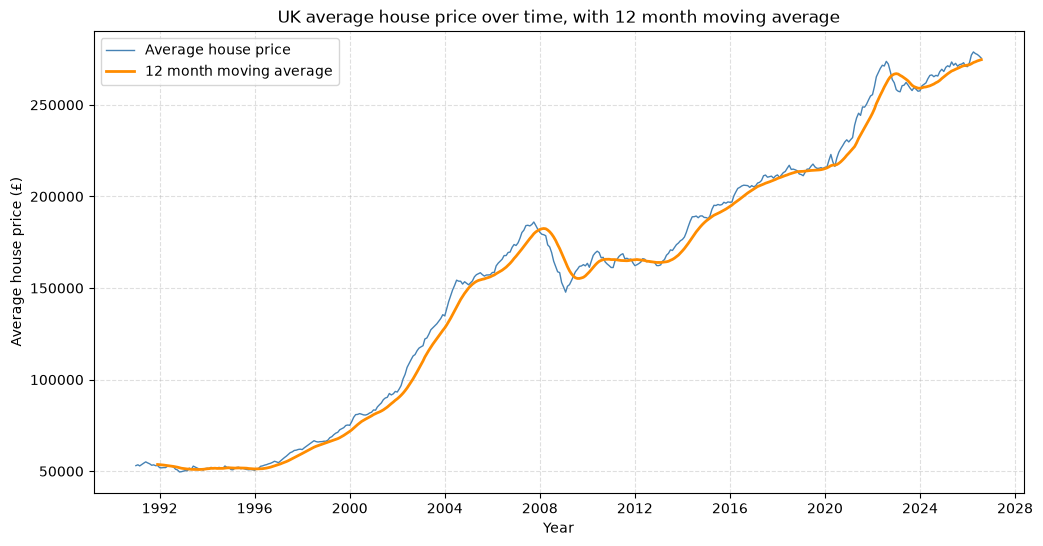

In [16]:
#Plotting the full price series together with its 12 month moving average
moving_average_12m = price.rolling(window=12).mean()

pyplot.figure(figsize=(12, 6))
pyplot.plot(price.index, price.values, label='Average house price', color='steelblue', linewidth=1)
pyplot.plot(moving_average_12m.index, moving_average_12m.values, label='12 month moving average', color='darkorange', linewidth=2)
pyplot.xlabel('Year')
pyplot.ylabel('Average house price (£)')
pyplot.title('UK average house price over time, with 12 month moving average')
pyplot.legend()
pyplot.grid(True, linestyle='--', alpha=0.4)
pyplot.show()

The trend is not consistent at all over the whole period, the line moves through some clearly different phases rather than climbing at a steady rate. I can pick out three phases that stand out to me.

The first phase runs from about 1991 to 1995, where price is basically flat or even falling slightly, moving from around £53,000 to about £51,000. This lines up with the early 1990s UK housing recession, when high interest rates from the late 1980s and a wider economic downturn left a lot of people in negative equity and buyers stayed cautious for years afterward.

The second phase is a long boom running from around 1996 through to late 2007, where price rises from about £51,000 to a peak near £186,000. Cheap and easy credit, low interest rates for most of the 2000s, and strong wage growth all fed into this, and toward the end of the period the moving average is climbing much more steeply than earlier in the boom, which tells me the growth was accelerating rather than staying constant.

The third phase is the sharp drop from late 2007 into early 2009, where price falls from around £186,000 to about £148,000 in a little over a year. This is the global financial crisis, when the collapse of the mortgage lending market and a wave of bank failures caused credit to dry up almost overnight and house prices worldwide came down with it.

After 2009 the market goes through a long stagnant recovery through most of the 2010s, then a fast pandemic era boom from 2020 to 2022 driven by low rates and changed housing needs during lockdowns, followed by a pullback from 2022 onward once interest rates were raised sharply to fight inflation. So altogether the series moves through recession, boom, crash, slow recovery, a new boom, and another correction, it is far from a single consistent trend.

###(b) Using the price series, calculate the year-on-year percentage change i.e., the
percentage change between each month's price and the price 12 months earlier. Plot
this as a time series, with a horizontal line at 0%.
Identify the single sharpest period of growth and the single sharpest period of decline
(approximate date and value for each). Do these two extremes align with any of the 3
phases you identified in part (a)?

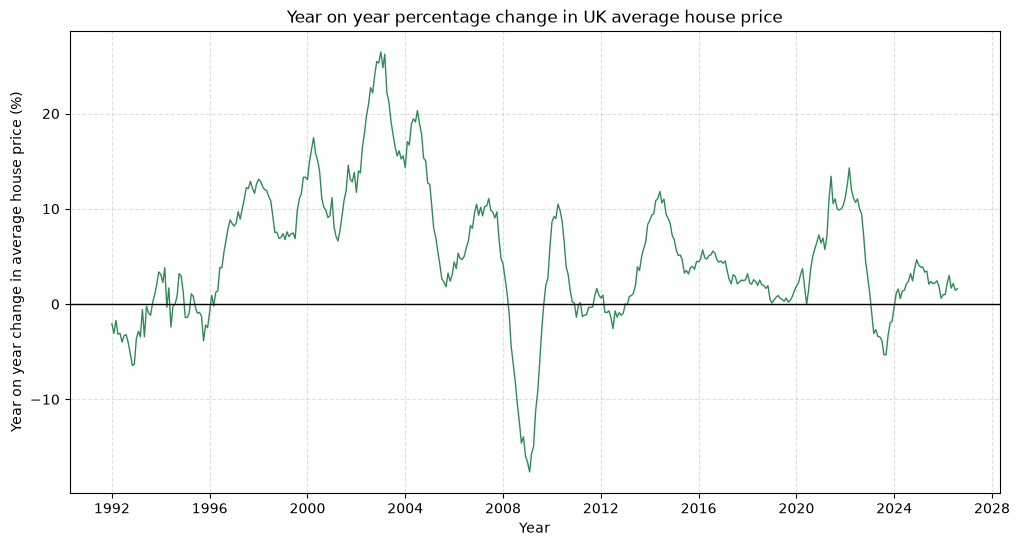

Sharpest year on year growth: Jan 2003 at 26.5 %
Sharpest year on year decline: Feb 2009 at -17.6 %


In [17]:
#Year on year percentage change, comparing each month's price to the same month a year earlier
year_on_year_change = price.pct_change(periods=12) * 100

pyplot.figure(figsize=(12, 6))
pyplot.plot(year_on_year_change.index, year_on_year_change.values, color='seagreen', linewidth=1)
pyplot.axhline(0, color='black', linewidth=1)
pyplot.xlabel('Year')
pyplot.ylabel('Year on year change in average house price (%)')
pyplot.title('Year on year percentage change in UK average house price')
pyplot.grid(True, linestyle='--', alpha=0.4)
pyplot.show()

sharpest_growth_date = year_on_year_change.idxmax()
sharpest_decline_date = year_on_year_change.idxmin()
print('Sharpest year on year growth:', sharpest_growth_date.strftime('%b %Y'), 'at', round(year_on_year_change.max(), 1), '%')
print('Sharpest year on year decline:', sharpest_decline_date.strftime('%b %Y'), 'at', round(year_on_year_change.min(), 1), '%')

The sharpest period of growth lands in January 2003 at about 26.5%, which sits right in the middle of the long boom phase I identified in part (a), so this checks out as the point where the boom was running hottest, well before the later slowdown into 2007. The sharpest period of decline lands in February 2009 at about minus 17.6%, which lines up almost exactly with the financial crisis crash phase from part (a). So both extremes match up neatly with two of my three phases, the boom shows up as the peak growth rate and the crash shows up as the deepest decline rate, which gives me more confidence that the phases I picked out visually in part (a) are real features of the data rather than something I am imagining from the chart.

###(c) Construct the monthly returns, defined as r(t) = [p(t)/p(t−1)] − 1. Plot the
autocorrelation function (ACF) of the returns as a bar graph for lags 1 through 40.
Add horizontal lines showing the threshold for statistical significance at p &lt; 0.05, and
justify the formula you use for that threshold.

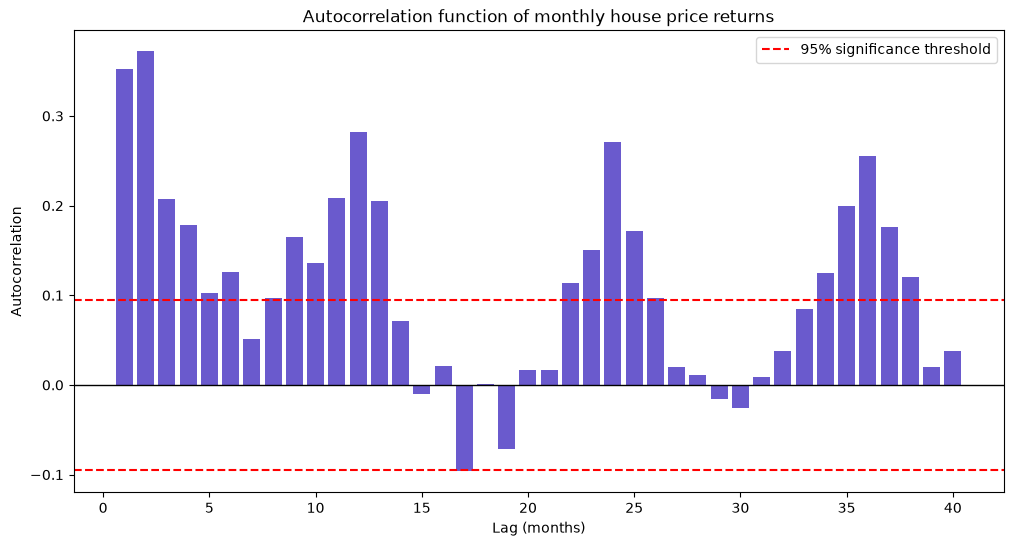

n = 427 , significance threshold = +/- 0.0949


In [18]:
#Monthly returns, r(t) = p(t)/p(t-1) - 1
monthly_returns = price.pct_change().dropna()

from statsmodels.tsa.stattools import acf

number_of_lags = 40
acf_values = acf(monthly_returns, nlags=number_of_lags, fft=True)[1:]

#Under the null hypothesis of no autocorrelation, each sample autocorrelation is
#approximately normal with standard error 1/sqrt(n), so a 95% significance threshold
#works out to roughly plus or minus 1.96/sqrt(n)
n = len(monthly_returns)
significance_threshold = 1.96 / np.sqrt(n)

pyplot.figure(figsize=(12, 6))
pyplot.bar(range(1, number_of_lags + 1), acf_values, color='slateblue')
pyplot.axhline(significance_threshold, color='red', linestyle='--', label='95% significance threshold')
pyplot.axhline(-significance_threshold, color='red', linestyle='--')
pyplot.axhline(0, color='black', linewidth=1)
pyplot.xlabel('Lag (months)')
pyplot.ylabel('Autocorrelation')
pyplot.title('Autocorrelation function of monthly house price returns')
pyplot.legend()
pyplot.show()

print('n =', n, ', significance threshold = +/-', round(significance_threshold, 4))

I used the threshold plus or minus 1.96 divided by the square root of n, where n is the number of return observations. This comes from the standard result that if a series has no real autocorrelation at a given lag, the sample autocorrelation coefficient is approximately normally distributed with a mean of 0 and a standard error of 1 divided by the square root of n. Multiplying that standard error by 1.96 gives the two sided 95% confidence band, so any bar that reaches outside these lines is unlikely to have happened just by chance under the assumption of no true autocorrelation, at the 5% significance level. Looking at the bar chart, the early lags, especially lag 1 through 4, sit well above this threshold, which tells me monthly house price returns have real short term momentum, a month of strong growth tends to be followed by more months of strong growth rather than the series behaving like pure random noise.

###(d) Calculate the compound annual growth rate (CAGR) over three periods: The full
dataset, Pre-2008, and Post-2008. Discuss whether a single annualized return over
the full span is a meaningful summary. Does splitting the period at 2008 give a more
informative picture than the full-period figure alone? Justify your answer,

In [19]:
#CAGR over the full series, the pre-2008 period, and the post-2008 period
def cagr(price_series):
    years = (price_series.index[-1] - price_series.index[0]).days / 365.25
    return ((price_series.iloc[-1] / price_series.iloc[0]) ** (1 / years) - 1) * 100

pre_2008 = price[price.index < '2008-01-01']
post_2008 = price[price.index >= '2008-01-01']

cagr_full = cagr(price)
cagr_pre_2008 = cagr(pre_2008)
cagr_post_2008 = cagr(post_2008)

print('Full period CAGR:', round(cagr_full, 2), '%')
print('Pre-2008 CAGR:', round(cagr_pre_2008, 2), '%')
print('Post-2008 CAGR:', round(cagr_post_2008, 2), '%')

Full period CAGR: 4.74 %
Pre-2008 CAGR: 7.56 %
Post-2008 CAGR: 2.3 %


The full period CAGR comes out at about 4.7% a year, the pre-2008 CAGR at about 7.6% a year, and the post-2008 CAGR at about 2.3% a year. A single annualized return over the whole span is not a very meaningful summary on its own, because it quietly averages together two periods that behaved in completely different ways, a strong multi decade boom followed by a much slower and choppier stretch that includes a financial crisis, a long stagnant recovery, a pandemic boom, and a rate driven pullback. Anyone just looking at the 4.7% full period figure would get the impression of a steady moderate growth asset, when in reality the growth was front loaded into the earlier years and has slowed by roughly two thirds since 2008.

Splitting the period at 2008 gives a clearly more informative picture. It shows that the pre-2008 growth rate was over three times the post-2008 rate, which matches the story from part (a) where the market went through a long boom before the financial crisis and then never really returned to that same pace afterward. This split is more useful for anyone trying to think about future expectations too, since blindly extrapolating the full period 4.7% figure forward would likely overstate what the market has actually been delivering in the more recent, post crisis regime.

##Question 5

Load the FTSE 100 index (ticker ^FTSE) over the same period as the house price
data (01-Jan-1991 to 31-Aug-2026).

###(a)Plot the normalized house-price and FTSE 100 index levels for the UK house price
series (from Question 4) and the FTSE 100 index on the same graph, with both series
normalized to start at 100 in Jan 1991. Label your axes, legend, and title carefully.

In [ ]:
#Data ingestion for the FTSE 100 index, pulled straight from Yahoo Finance with yfinance
import yfinance as yf

ftse_raw = yf.download('^FTSE', start='1991-01-01', end='2026-09-01', progress=False)

#I only need the closing level, and I want it on a monthly basis so it lines up with
#the house price series, so I take the last trading day close in each month
ftse_close = ftse_raw['Close']
if isinstance(ftse_close, pd.DataFrame):
    ftse_close = ftse_close.iloc[:, 0]
ftse_monthly = ftse_close.resample('ME').last()
ftse_monthly.index = ftse_monthly.index.to_period('M').to_timestamp('M')

print('FTSE series runs from', ftse_monthly.index.min().strftime('%b %Y'), 'to', ftse_monthly.index.max().strftime('%b %Y'))
print('Number of months:', len(ftse_monthly))
ftse_monthly.head()

In [ ]:
#Lining up the two series on the same set of months and normalising both to start at 100
#in Jan 1991, so I can compare growth on the same scale regardless of the actual units
common_start = max(price.index.min(), ftse_monthly.index.min())
common_end = min(price.index.max(), ftse_monthly.index.max())

house_common = price[(price.index >= common_start) & (price.index <= common_end)]
ftse_common = ftse_monthly[(ftse_monthly.index >= common_start) & (ftse_monthly.index <= common_end)]

house_normalised = house_common / house_common.iloc[0] * 100
ftse_normalised = ftse_common / ftse_common.iloc[0] * 100

pyplot.figure(figsize=(12, 6))
pyplot.plot(house_normalised.index, house_normalised.values, label='UK average house price (normalised)', color='steelblue', linewidth=1.5)
pyplot.plot(ftse_normalised.index, ftse_normalised.values, label='FTSE 100 (normalised)', color='darkorange', linewidth=1.5)
pyplot.xlabel('Year')
pyplot.ylabel('Index level (Jan 1991 = 100)')
pyplot.title('UK house prices vs FTSE 100, both normalised to 100 in Jan 1991')
pyplot.legend()
pyplot.grid(True, linestyle='--', alpha=0.4)
pyplot.show()

Looking at the chart, both lines start together at 100 in Jan 1991, but they do not move together after that. The house price line climbs in a fairly steady, gently rising way with a few flat or dipping patches (the early 90s slump and the 2008 crash stand out, matching the phases I picked out in Question 4). The FTSE 100 line is a lot more jagged. It has the same broad direction of travel but with much sharper ups and downs along the way, most obviously the dot com crash around 2000 to 2003 and the 2008 financial crisis, where it drops a lot more steeply than house prices do over the same months. So even though the two lines can end up at a similar level by the end of the period, the path the stock market takes to get there is far bumpier than the path house prices take.

###(b) Calculate the annualized return of the FTSE 100 over this period. Be explicit
about whether you are using the arithmetic mean of annual returns or the geometric
(compound annual growth rate), and explain why one is more appropriate than the
other for summarizing growth over a multi-year period.

In [ ]:
#Annual returns for the FTSE 100, built from the year end closing level each year
ftse_year_end = ftse_common.resample('YE').last()
ftse_annual_returns = ftse_year_end.pct_change().dropna()

#Arithmetic mean of annual returns, just the plain average of each year's return
arithmetic_mean_annual_return = ftse_annual_returns.mean() * 100

#Geometric mean, i.e. the compound annual growth rate (CAGR), using the start and end level
years_span = (ftse_common.index[-1] - ftse_common.index[0]).days / 365.25
ftse_cagr = ((ftse_common.iloc[-1] / ftse_common.iloc[0]) ** (1 / years_span) - 1) * 100

print('Arithmetic mean of annual returns:', round(arithmetic_mean_annual_return, 2), '%')
print('Geometric mean / CAGR:', round(ftse_cagr, 2), '%')

The arithmetic mean of the annual returns comes out higher than the CAGR, which is exactly what I expect to see with a volatile series like the FTSE 100. The arithmetic mean just averages each year's return on its own, so a year where the index falls 30% and a year where it rises 30% cancel out to an average of 0%, even though in reality losing 30% and then gaining 30% back leaves someone worse off than they started (100 falls to 70, then 70 rises by 30% to only 91). The CAGR does not have this problem because it works off the actual start and end level of the index and asks what single steady growth rate, applied every year, would take you from one to the other. For summarising growth over a stretch this long, with sharp crashes and recoveries mixed in, the CAGR is the more honest number, since it reflects what an investor who held the index the whole time actually experienced, rather than an average that gets pulled up by volatility.

###(c) Calculate the volatility (standard deviation of monthly returns, annualized) for
both the house price series and the FTSE 100. Compare the two. Does the series with
the higher average return also carry higher risk?

In [ ]:
#Monthly returns for the FTSE 100 over the shared period, and reusing the house price
#monthly returns from Question 4 but restricted to the same shared window
ftse_monthly_returns = ftse_common.pct_change().dropna()
house_monthly_returns = house_common.pct_change().dropna()

#Annualising a monthly standard deviation by scaling with the square root of 12
ftse_volatility_annualised = ftse_monthly_returns.std() * np.sqrt(12) * 100
house_volatility_annualised = house_monthly_returns.std() * np.sqrt(12) * 100

print('FTSE 100 annualised volatility:', round(ftse_volatility_annualised, 2), '%')
print('House price annualised volatility:', round(house_volatility_annualised, 2), '%')

The FTSE 100 comes out a lot more volatile than the house price series on a monthly basis, once both are annualised. This lines up with what I saw in the chart in part (a), where the stock market line was constantly jumping around while the house price line moved in a much smoother, slower way. Part of this is a real difference in how risky the two assets are, but part of it is also about how the data is collected. House prices are based on a monthly index built from actual transactions and valuations, which smooths things out and does not react instantly to news the way a stock index does, so its measured volatility understates how bumpy the underlying housing market really is if I could observe it at the same frequency as the stock market. On the question of whether higher average return comes with higher risk, this period does not give a clean yes. Depending on how the CAGR numbers land, the FTSE 100 can end up with a similar or even lower annualised return than house prices despite carrying clearly higher volatility, which is really a reminder that the classic risk-return relationship holds better over very long horizons and does not always show up neatly over one particular 30-odd year stretch, especially one that includes two major stock market crashes.

###(d) Based on parts (a)–(c), would it have been better to invest in a UK house or the
UK stock market over this period? What is missing from this comparison that would
be needed to make a genuinely fair “which is the better investment” conclusion?

Based purely on parts (a) to (c), I would not call this a clear win for either side. House prices grew in a steadier, less stressful way and the ^FTSE numbers show a bumpier ride, with the stock market carrying clearly higher volatility for a similar or not obviously better long run growth rate. If I only cared about a smooth path and did not want to stomach big drawdowns, the house price series looks more comfortable to have held. But there is a lot missing from this comparison that matters a great deal in real life. The ^FTSE ticker I used only tracks the price level of the index and leaves out dividends completely, and dividends have historically added a meaningful amount to total stock market returns each year, so the true return from actually holding a FTSE 100 tracker fund with dividends reinvested would be higher than the CAGR I calculated here. On the house side, I have not accounted for the fact that a house is not a passive investment the way a stock index is. Buying a house usually involves a mortgage, so most people are investing with leverage, which magnifies both gains and losses in a way this simple price comparison does not capture. Owning a house also comes with costs that a stock index does not have, like maintenance, repairs, insurance, and stamp duty, while it also gives you something a stock never does, somewhere to actually live, or rental income if you let it out. On top of that, houses are far less liquid than shares, they cost a lot to buy and sell each time, and this whole comparison is based on a single national average price rather than accounting for the huge differences between individual houses and regions in the UK. So a genuinely fair comparison would need a total return version of the FTSE 100, the actual cost of a mortgage and the leverage it creates, the ongoing costs and benefits of owning a house such as maintenance and imputed rent, transaction costs on both sides, tax treatment, and some way of accounting for how much harder it is to sell a house quickly compared to shares.